<a href="https://colab.research.google.com/github/JayeshPatil1234/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/jayesh-patil/notebooks/lstm_energy_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [4]:
import pandas as pd

df = pd.read_csv("smart_home_energy_consumption_large.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
50817,389,TV,1.83,09:04,2023-01-01,10.6,Winter,1
26314,300,Air Conditioning,4.76,23:56,2023-01-01,-3.8,Winter,4
61414,182,TV,0.89,16:31,2023-01-01,-6.9,Winter,5
38070,467,Oven,1.40,16:52,2023-01-01,34.6,Winter,1
45311,390,Heater,4.41,20:45,2023-01-01,16.2,Winter,4


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler.fit_transform(df[['Energy Consumption (kWh)']])


In [6]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 24
X, y = create_sequences(energy_scaled, TIME_STEPS)


In [7]:
split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [8]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [9]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, 1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 0.0613 - val_loss: 0.0581
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0586 - val_loss: 0.0579
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0586 - val_loss: 0.0580
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0578 - val_loss: 0.0579
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0584 - val_loss: 0.0579
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0577 - val_loss: 0.0579
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0584 - val_loss: 0.0579
Epoch 8/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0578 - val_loss: 0.0579
Epoch 9/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0580 - val_loss: 0.0579


In [11]:
y_pred_scaled = model.predict(X_test)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [12]:

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)


LSTM MAE: 0.892630034154786
LSTM RMSE: 1.172998902105627


In [13]:
model.save("lstm_energy_model.h5")


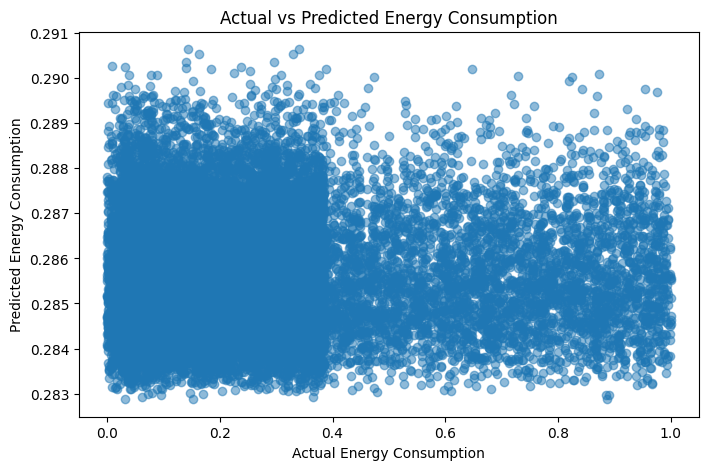

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_scaled, alpha=0.5)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()


In [15]:
# Week 6 Work
y_pred = model.predict(X_test)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [16]:
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))



In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)
print("LSTM R2:", r2)


LSTM MAE: 0.892630034154786
LSTM RMSE: 1.172998902105627
LSTM R2: -0.00011986558874754749


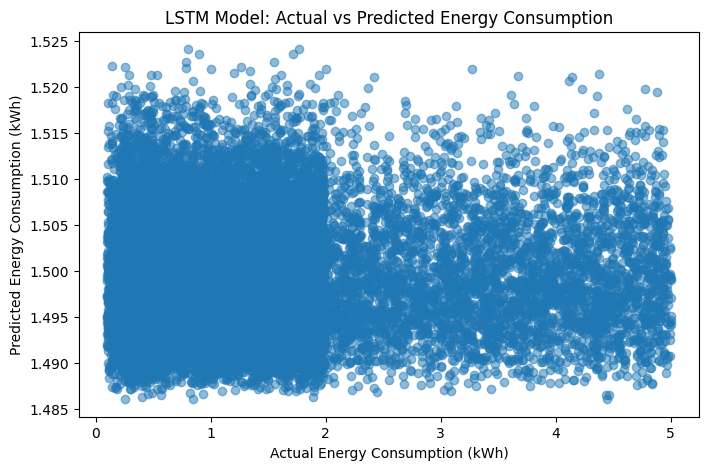

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("LSTM Model: Actual vs Predicted Energy Consumption")
plt.show()


In [19]:
# Save trained LSTM model
model.save("lstm_model.keras")

# Save scaler
import joblib
joblib.dump(scaler, "scaler.save")

print("Model and scaler saved successfully")


Model and scaler saved successfully
